# `fourierror` usage

`fourierror` propagates measurement uncertainty through a discrete Fourier transform. 
It offers three entry points, and the point of this notebook is to show what each one is for and where they agree:

| Function | Method | Cost |
|---|---|---|
| `analytical.dft` | exact propagation through the DFT matrix | one matrix product |
| `numerical.dft`  | Monte Carlo sampling of the input distribution | `n_samples` transforms |
| `numerical.fft`  | Monte Carlo sampling, via the FFT | `n_samples` transforms, faster |

Everything is built on [`scipp`](https://scipp.github.io), so inputs carry units, coordinates and variances, and the frequency axis is derived for you.

In [1]:
import numpy as np
import scipp as sc
import matplotlib.pyplot as plt

from fourierror import analytical, numerical

## Input data

A damped cosine, measured with noise that grows over time — so the input variances are *not* all equal. 
That is the interesting case: a single "average" error bar would not capture it.

The input is a `scipp.DataArray` whose data has `variances` and whose coordinate carries a unit.

In [2]:
rng = np.random.default_rng(42)

N, dt = 128, 0.05
t = np.arange(N) * dt
truth = np.exp(-t / 1.5) * np.cos(2 * np.pi * 1.5 * t)

sigma = 0.05 + 0.15 * (t / t.max())          # noise grows with time
measured = truth + rng.normal(0.0, sigma)

data = sc.DataArray(
    data=sc.array(dims=["t"], values=measured, variances=sigma**2),
    coords={"t": sc.array(dims=["t"], values=t, unit="s")},
)
data

<scipp.DataArray>
Dimensions: Sizes[t:128, ]
Coordinates:
* t                         float64              [s]  (t)  [0, 0.05, ..., 6.3, 6.35]
Data:
                            float64  [dimensionless]  (t)  [1.01524, 0.808568, ..., 0.276671, -0.252078]  [0.0025, 0.00261951, ..., 0.039529, 0.04]

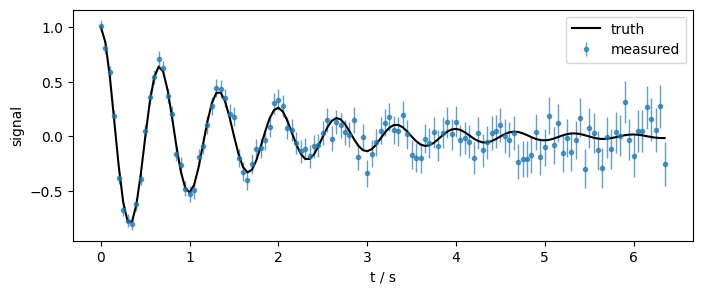

In [3]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(t, measured, yerr=sigma, fmt="o", ms=3, lw=1, alpha=0.7, label="measured")
ax.plot(t, truth, "k-", lw=1.5, label="truth")
ax.set(xlabel="t / s", ylabel="signal")
ax.legend()
plt.show()

## Exact propagation

The DFT is linear, so an input covariance maps onto the output exactly: `cos @ cov @ cos.T` for the real part and `sin @ cov @ sin.T` for the imaginary part. 
No sampling, no tuning parameter — just one matrix product.

The result is a `scipp.Dataset` with `real` and `imag` entries, each carrying its own variances, on an `omega` axis.

In [4]:
ana = analytical.dft(data, "t")
ana

<scipp.Dataset>
Dimensions: Sizes[omega:128, ]
Coordinates:
* omega                     float64             [Hz]  (omega)  [0, 0.981748, ..., -1.9635, -0.981748]
Data:
  imag                      float64  [dimensionless]  (omega)  [0, -0.0242925, ..., -0.00737463, 0.0242925]  [0, 0.00027169, ..., 0.000275082, 0.00027169]
  real                      float64  [dimensionless]  (omega)  [-0.00434913, 0.0170045, ..., 0.0261698, 0.0170045]  [0.000547798, 0.000276108, ..., 0.000272716, 0.000276108]

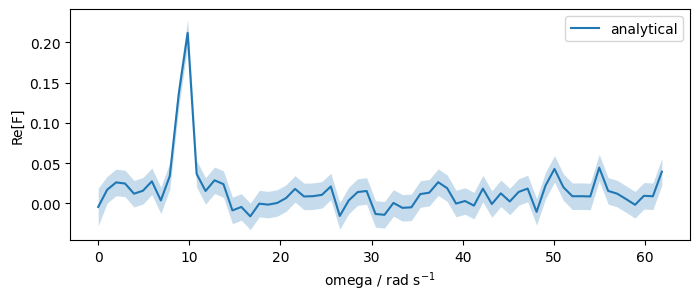

In [5]:
def plot_spectrum(ds, ax, label, **kw):
    """Plot the positive-frequency real part with a 1-sigma band."""
    w = ds.coords["omega"].values
    keep = w >= 0
    v = ds["real"].values[keep]
    e = np.sqrt(ds["real"].variances[keep])
    ax.plot(w[keep], v, label=label, **kw)
    ax.fill_between(w[keep], v - e, v + e, alpha=0.25, lw=0, **kw)

fig, ax = plt.subplots(figsize=(8, 3))
plot_spectrum(ana, ax, "analytical", color="C0")
ax.set(xlabel="omega / rad s$^{-1}$", ylabel="Re[F]")
ax.legend()
plt.show()

## Monte Carlo

The numerical route draws `n_samples` realisations from a multivariate normal built from the input values and variances, transforms every one of them, and
takes the mean and covariance of the results.

It is (usually) slower and stochastic, but it makes no assumptions about how the uncertainty propagates — which is what makes it the reference when you want to *check* the analytical result, or when the analytical assumptions do not hold.

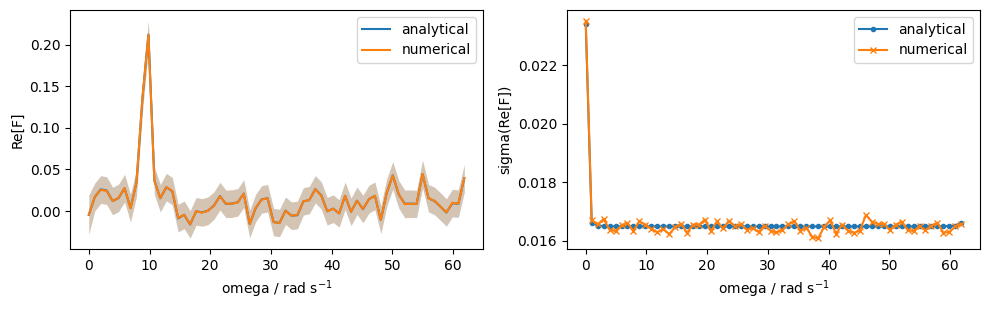

In [10]:
num = numerical.dft(data, "t", n_samples=5_000)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
plot_spectrum(ana, axes[0], "analytical", color="C0")
plot_spectrum(num, axes[0], "numerical", color="C1")
axes[0].set(xlabel="omega / rad s$^{-1}$", ylabel="Re[F]")
axes[0].legend()

w = ana.coords["omega"].values
keep = w >= 0
axes[1].plot(w[keep], np.sqrt(ana["real"].variances[keep]), "o-", ms=3, label="analytical")
axes[1].plot(w[keep], np.sqrt(num["real"].variances[keep]), "x-", ms=4, label="numerical")
axes[1].set(xlabel="omega / rad s$^{-1}$", ylabel="sigma(Re[F])")
axes[1].legend()
plt.tight_layout()
plt.show()

In [11]:
sd_a = np.sqrt(ana["real"].variances)
sd_n = np.sqrt(num["real"].variances)
print(f"max relative difference in sigma: {np.abs(sd_n / sd_a - 1).max():.2%}")

max relative difference in sigma: 2.44%


The two agree to within Monte Carlo noise, and the sampling error shrinks as `n_samples` grows — the usual $1/\sqrt{n}$ convergence.

In [12]:
for n in (100, 500, 2_500, 12_500):
    sd = np.sqrt(numerical.dft(data, "t", n_samples=n)["real"].variances)
    print(f"n_samples = {n:6d}   max relative difference = {np.abs(sd / sd_a - 1).max():.2%}")

n_samples =    100   max relative difference = 15.38%
n_samples =    500   max relative difference = 9.37%
n_samples =   2500   max relative difference = 3.45%
n_samples =  12500   max relative difference = 1.58%


## Fast Fourier transform

`numerical.fft` samples in exactly the same way but uses `np.fft.fft` instead of an explicit DFT matrix, which is the difference between O(N²) and O(N log N) per sample.

*We are in the process of developing an FFT analytical form*.  

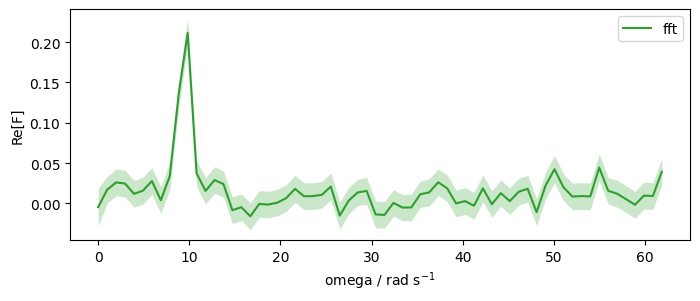

In [15]:
fast = numerical.fft(data, "t", n_samples=5_000)

fig, ax = plt.subplots(figsize=(8, 3))
plot_spectrum(fast, ax, "fft", color="C2")
ax.set(xlabel="omega / rad s$^{-1}$", ylabel="Re[F]")
ax.legend()
plt.show()